
- ¿Cómo evolucionaron las ventas a lo largo del tiempo?
- ¿Cuáles son las categorías de productos más vendidas?
- ¿Cuáles son los estados con más pedidos?
- ¿Cómo es la satisfacción de los clientes?
- ¿Cuánto demora la entrega y afecta la satisfacción?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Librerías cargadas correctamente 🚀")

Librerías cargadas correctamente 🚀


In [3]:
# Cargamos todos los archivos CSV
customers = pd.read_csv('data/olist_customers_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_sellers_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

print("Datasets cargados correctamente ✅")

Datasets cargados correctamente ✅


In [4]:
# Resumen de todos los datasets
datasets = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

for nombre, df in datasets.items():
    print(f"📦 {nombre}")
    print(f"   Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
    print(f"   Columnas: {list(df.columns)}")
    print()

📦 customers
   Filas: 99,441 | Columnas: 5
   Columnas: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

📦 geolocation
   Filas: 1,000,163 | Columnas: 5
   Columnas: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

📦 order_items
   Filas: 112,650 | Columnas: 7
   Columnas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

📦 payments
   Filas: 103,886 | Columnas: 5
   Columnas: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

📦 reviews
   Filas: 99,224 | Columnas: 7
   Columnas: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

📦 orders
   Filas: 99,441 | Columnas: 8
   Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_del

In [5]:
# Revisamos la calidad de la tabla principal
print("=== CALIDAD DE DATOS: ORDERS ===")
print(f"\nValores nulos por columna:")
print(orders.isnull().sum())
print(f"\nEstados de pedidos:")
print(orders['order_status'].value_counts())

=== CALIDAD DE DATOS: ORDERS ===

Valores nulos por columna:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Estados de pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [6]:
# Filtramos solo pedidos entregados
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Convertimos fechas a formato datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_delivered[col] = pd.to_datetime(orders_delivered[col])

# Calculamos el tiempo real de entrega en días
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] - 
    orders_delivered['order_purchase_timestamp']
).dt.days

print(f"Pedidos entregados: {len(orders_delivered):,}")
print(f"\nTiempo de entrega promedio: {orders_delivered['delivery_days'].mean():.1f} días")
print(f"Tiempo de entrega mínimo: {orders_delivered['delivery_days'].min()} días")
print(f"Tiempo de entrega máximo: {orders_delivered['delivery_days'].max()} días")

Pedidos entregados: 96,478

Tiempo de entrega promedio: 12.1 días
Tiempo de entrega mínimo: 0.0 días
Tiempo de entrega máximo: 209.0 días


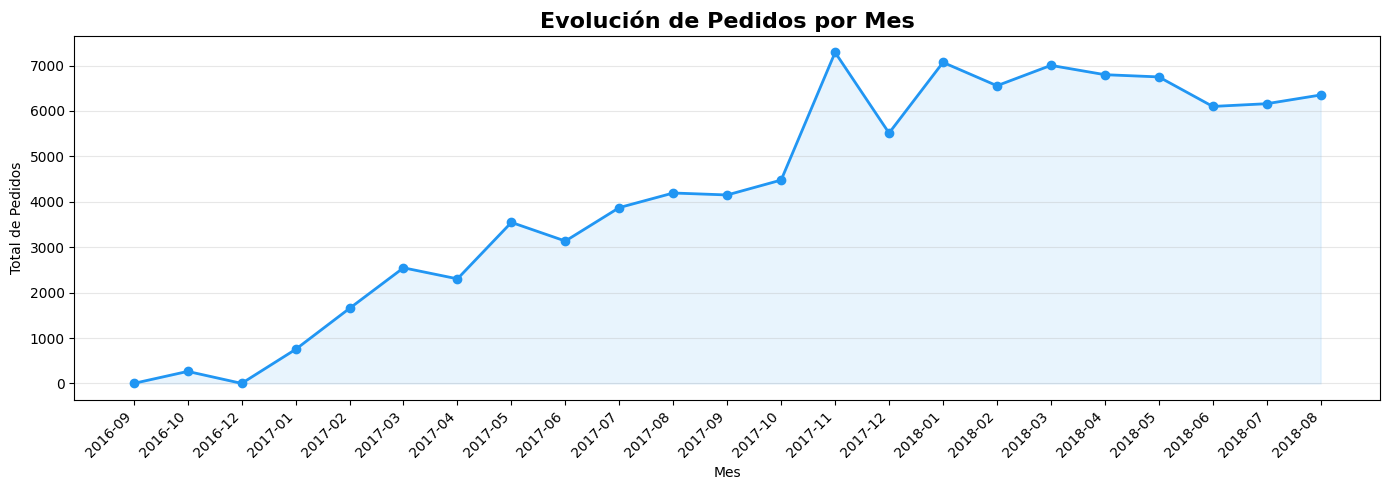


Mes con más pedidos: 2017-11
Total pedidos ese mes: 7,289


In [7]:
# Creamos columna de año y mes
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

# Contamos pedidos por mes
ventas_por_mes = orders_delivered.groupby('year_month').size().reset_index(name='total_pedidos')
ventas_por_mes['year_month'] = ventas_por_mes['year_month'].astype(str)

# Graficamos
plt.figure(figsize=(14, 5))
plt.plot(ventas_por_mes['year_month'], ventas_por_mes['total_pedidos'], 
         marker='o', linewidth=2, color='#2196F3')
plt.fill_between(range(len(ventas_por_mes)), ventas_por_mes['total_pedidos'], 
                 alpha=0.1, color='#2196F3')
plt.xticks(range(len(ventas_por_mes)), ventas_por_mes['year_month'], rotation=45, ha='right')
plt.title('Evolución de Pedidos por Mes', fontsize=16, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Total de Pedidos')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMes con más pedidos: {ventas_por_mes.loc[ventas_por_mes['total_pedidos'].idxmax(), 'year_month']}")
print(f"Total pedidos ese mes: {ventas_por_mes['total_pedidos'].max():,}")

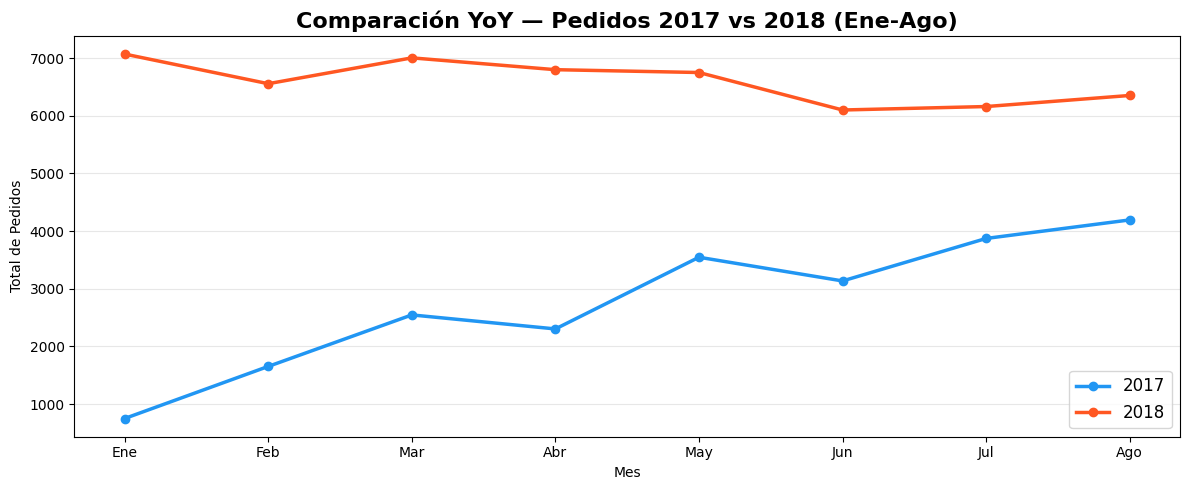

            2017  2018  crecimiento_%
mes_nombre                           
Abr         2303  6798          195.2
Ago         4193  6351           51.5
Ene          750  7069          842.5
Feb         1653  6555          296.6
Jul         3872  6159           59.1
Jun         3135  6099           94.5
Mar         2546  7003          175.1
May         3546  6749           90.3


In [8]:
# Filtramos 2017 y 2018
orders_delivered['year'] = orders_delivered['order_purchase_timestamp'].dt.year
orders_delivered['month'] = orders_delivered['order_purchase_timestamp'].dt.month

yoy = orders_delivered[orders_delivered['year'].isin([2017, 2018])]

# Agrupamos por año y mes
yoy_grouped = yoy.groupby(['year', 'month']).size().reset_index(name='total_pedidos')

# Filtramos solo enero a agosto (meses comparables)
yoy_grouped = yoy_grouped[yoy_grouped['month'] <= 8]

# Nombres de meses
meses = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago'}
yoy_grouped['mes_nombre'] = yoy_grouped['month'].map(meses)

# Graficamos
fig, ax = plt.subplots(figsize=(12, 5))

for year, color in [(2017, '#2196F3'), (2018, '#FF5722')]:
    data = yoy_grouped[yoy_grouped['year'] == year]
    ax.plot(data['mes_nombre'], data['total_pedidos'], 
            marker='o', linewidth=2.5, color=color, label=str(year))

ax.set_title('Comparación YoY — Pedidos 2017 vs 2018 (Ene-Ago)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Total de Pedidos')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Calculamos crecimiento por mes
pivot = yoy_grouped.pivot(index='mes_nombre', columns='year', values='total_pedidos')
pivot.columns = ['2017', '2018']
pivot['crecimiento_%'] = ((pivot['2018'] - pivot['2017']) / pivot['2017'] * 100).round(1)
print(pivot.to_string())

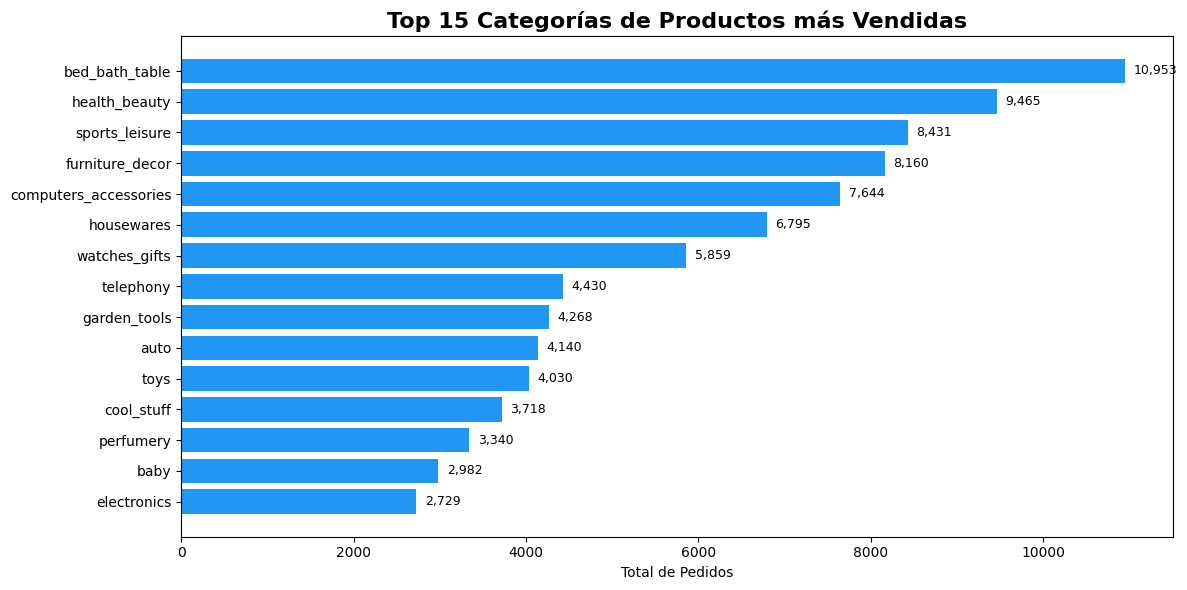


Top 5 categorías:
            categoria  total_pedidos
       bed_bath_table          10953
        health_beauty           9465
       sports_leisure           8431
      furniture_decor           8160
computers_accessories           7644


In [9]:
# Cargamos products correctamente (antes lo cargamos mal)
products = pd.read_csv('data/olist_products_dataset.csv')

# Unimos las tablas necesarias
df = orders_delivered[['order_id']].merge(order_items, on='order_id')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id')
df = df.merge(category_translation, on='product_category_name', how='left')

# Usamos nombre en inglés cuando existe, sino el original
df['categoria'] = df['product_category_name_english'].fillna(df['product_category_name'])

# Top 15 categorías por cantidad de pedidos
top_categorias = (df.groupby('categoria')
                    .size()
                    .reset_index(name='total_pedidos')
                    .sort_values('total_pedidos', ascending=False)
                    .head(15))

# Graficamos
plt.figure(figsize=(12, 6))
bars = plt.barh(top_categorias['categoria'], top_categorias['total_pedidos'], 
                color='#2196F3')
plt.title('Top 15 Categorías de Productos más Vendidas', fontsize=16, fontweight='bold')
plt.xlabel('Total de Pedidos')
plt.gca().invert_yaxis()

# Agregamos valores en las barras
for bar, value in zip(bars, top_categorias['total_pedidos']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
             f'{value:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 categorías:")
print(top_categorias.head().to_string(index=False))

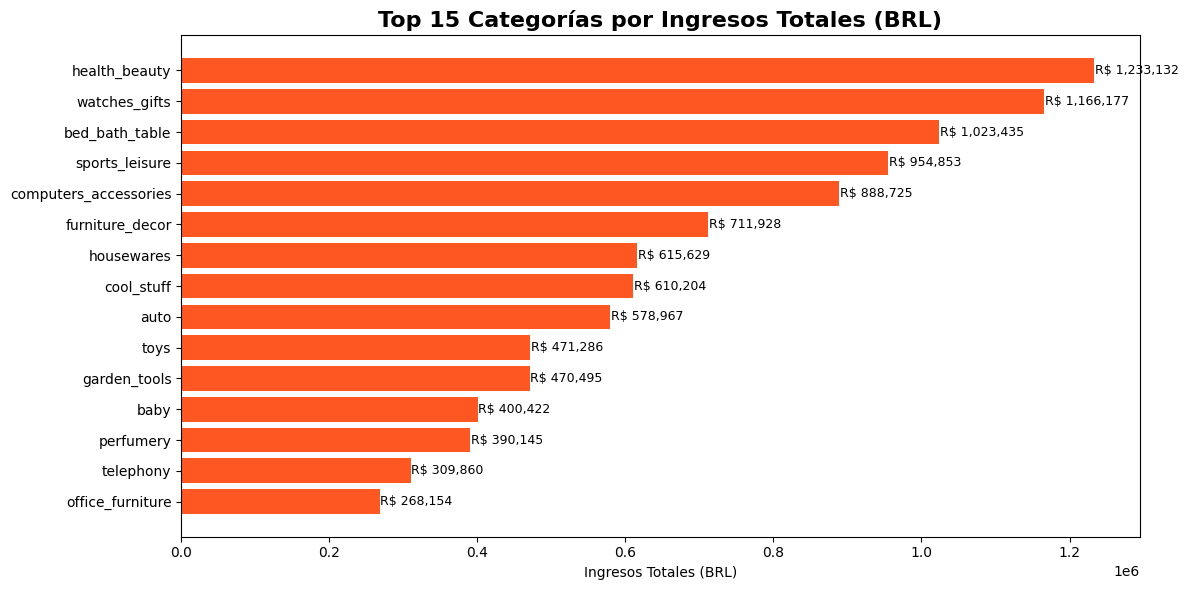


Top 5 categorías por ingresos:
            categoria  ingresos_totales
        health_beauty         1233132.0
        watches_gifts         1166177.0
       bed_bath_table         1023435.0
       sports_leisure          954853.0
computers_accessories          888725.0


In [10]:
# Unimos precio a nuestro dataframe
df_ingresos = orders_delivered[['order_id']].merge(order_items, on='order_id')
df_ingresos = df_ingresos.merge(products[['product_id', 'product_category_name']], on='product_id')
df_ingresos = df_ingresos.merge(category_translation, on='product_category_name', how='left')
df_ingresos['categoria'] = df_ingresos['product_category_name_english'].fillna(df_ingresos['product_category_name'])

# Top 15 categorías por ingresos
top_ingresos = (df_ingresos.groupby('categoria')['price']
                            .sum()
                            .reset_index(name='ingresos_totales')
                            .sort_values('ingresos_totales', ascending=False)
                            .head(15))

top_ingresos['ingresos_totales'] = top_ingresos['ingresos_totales'].round(0)

# Graficamos
plt.figure(figsize=(12, 6))
bars = plt.barh(top_ingresos['categoria'], top_ingresos['ingresos_totales'], 
                color='#FF5722')
plt.title('Top 15 Categorías por Ingresos Totales (BRL)', fontsize=16, fontweight='bold')
plt.xlabel('Ingresos Totales (BRL)')
plt.gca().invert_yaxis()

for bar, value in zip(bars, top_ingresos['ingresos_totales']):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'R$ {value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 categorías por ingresos:")
print(top_ingresos.head().to_string(index=False))

watches_gifts no vende tanto en volumen pero genera muchísimo ingreso significa que son productos de ticket alto..
bed_bath_table lidera en volumen pero cae en ingresos productos de bajo precio pero alta rotación.

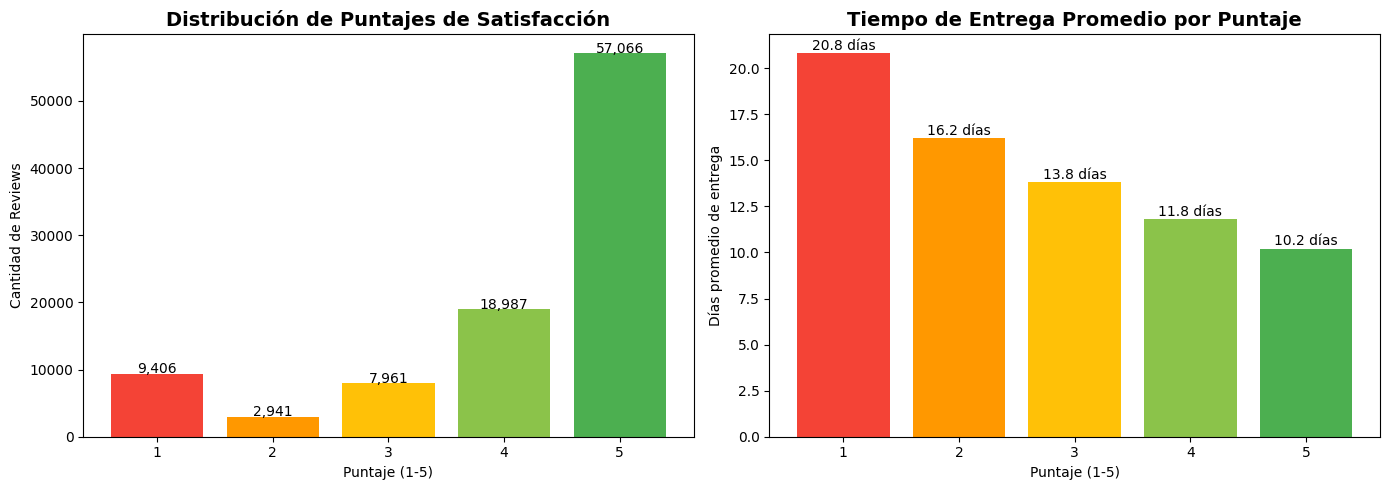

Puntaje promedio: 4.16 / 5.0
Pedidos con 5 estrellas: 59.2%
Pedidos con 1 estrella: 9.8%

Tiempo de entrega promedio por puntaje:
review_score
1    20.8
2    16.2
3    13.8
4    11.8
5    10.2


In [11]:
# Unimos reviews con orders_delivered
df_reviews = orders_delivered[['order_id', 'delivery_days']].merge(reviews, on='order_id')

# Distribución de puntajes
score_counts = df_reviews['review_score'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Distribución de puntajes
colors = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
bars = ax1.bar(score_counts.index, score_counts.values, color=colors)
ax1.set_title('Distribución de Puntajes de Satisfacción', fontsize=14, fontweight='bold')
ax1.set_xlabel('Puntaje (1-5)')
ax1.set_ylabel('Cantidad de Reviews')
for bar, value in zip(bars, score_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{value:,}', ha='center', fontsize=10)

# Gráfico 2 — Tiempo de entrega promedio por puntaje
entrega_por_score = df_reviews.groupby('review_score')['delivery_days'].mean().round(1)
bars2 = ax2.bar(entrega_por_score.index, entrega_por_score.values, color=colors)
ax2.set_title('Tiempo de Entrega Promedio por Puntaje', fontsize=14, fontweight='bold')
ax2.set_xlabel('Puntaje (1-5)')
ax2.set_ylabel('Días promedio de entrega')
for bar, value in zip(bars2, entrega_por_score.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{value} días', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Métricas clave
promedio = df_reviews['review_score'].mean()
cinco_estrellas = (score_counts[5] / score_counts.sum() * 100).round(1)
una_estrella = (score_counts[1] / score_counts.sum() * 100).round(1)

print(f"Puntaje promedio: {promedio:.2f} / 5.0")
print(f"Pedidos con 5 estrellas: {cinco_estrellas}%")
print(f"Pedidos con 1 estrella: {una_estrella}%")
print(f"\nTiempo de entrega promedio por puntaje:")
print(entrega_por_score.to_string())

Los clientes insatisfechos esperan el doble que los satisfechos


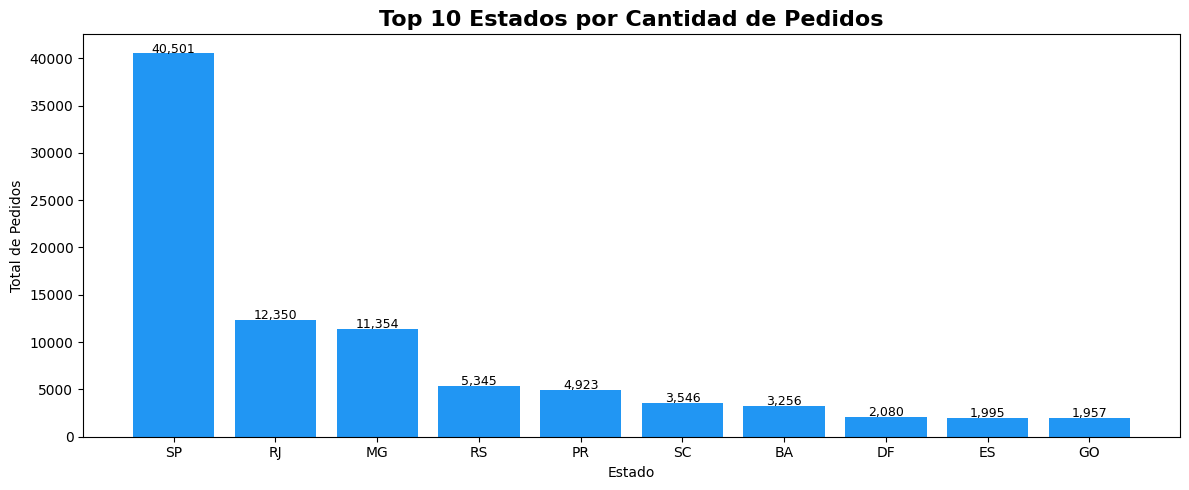


Top 10 estados:
customer_state  total_pedidos
            SP          40501
            RJ          12350
            MG          11354
            RS           5345
            PR           4923
            SC           3546
            BA           3256
            DF           2080
            ES           1995
            GO           1957


In [12]:
# Unimos orders con customers para obtener el estado
df_geo = orders_delivered[['order_id']].merge(
    customers[['customer_id', 'customer_state']], 
    left_on='order_id', 
    right_on='customer_id', 
    how='left'
)

# Intentamos de otra forma — uniendo por customer_id desde orders
df_geo = orders_delivered[['order_id', 'customer_id']].merge(
    customers[['customer_id', 'customer_state']], 
    on='customer_id'
)

# Pedidos por estado
pedidos_por_estado = (df_geo.groupby('customer_state')
                             .size()
                             .reset_index(name='total_pedidos')
                             .sort_values('total_pedidos', ascending=False))

# Graficamos top 10
top10_estados = pedidos_por_estado.head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(top10_estados['customer_state'], top10_estados['total_pedidos'],
               color='#2196F3')
plt.title('Top 10 Estados por Cantidad de Pedidos', fontsize=16, fontweight='bold')
plt.xlabel('Estado')
plt.ylabel('Total de Pedidos')

for bar, value in zip(bars, top10_estados['total_pedidos']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{value:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 estados:")
print(pedidos_por_estado.head(10).to_string(index=False))

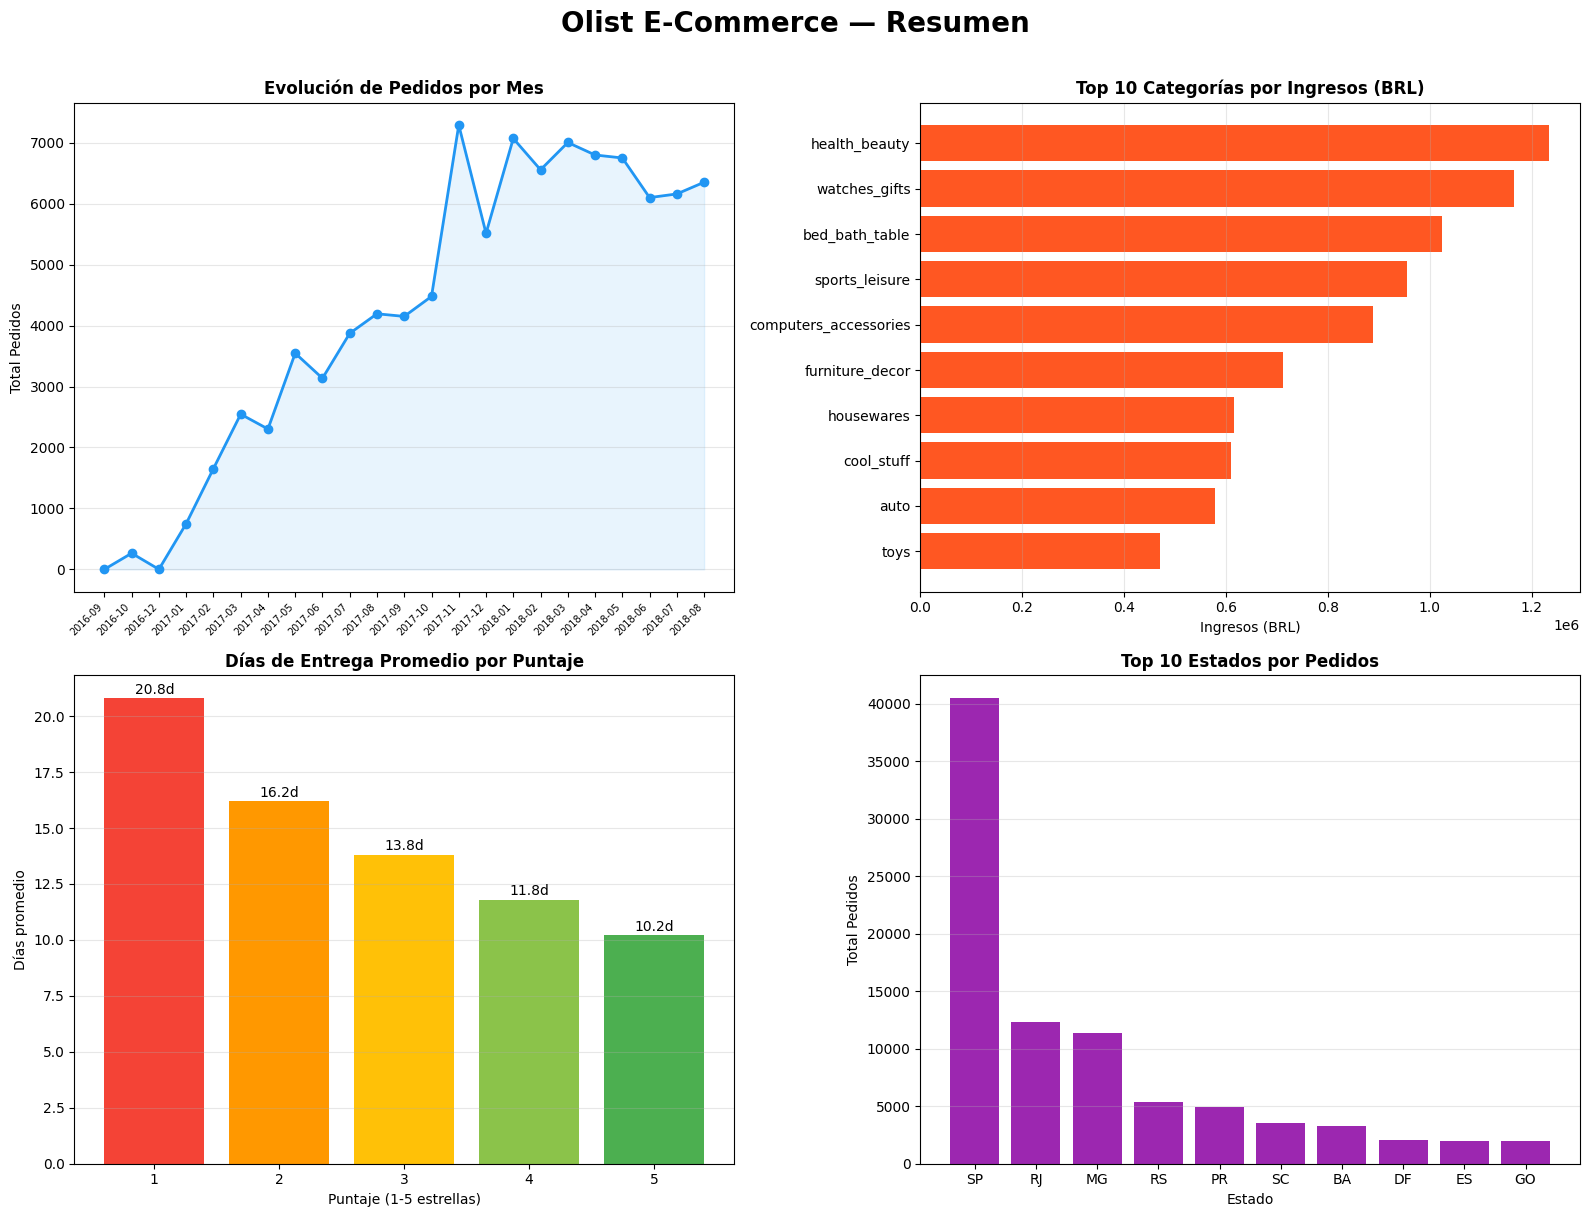

Dashboard guardado como olist_resumen_ejecutivo.png ✅


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Olist E-Commerce — Resumen', fontsize=20, fontweight='bold', y=1.01)

# --- Gráfico 1: Evolución de ventas ---
ax1 = axes[0, 0]
ax1.plot(ventas_por_mes['year_month'], ventas_por_mes['total_pedidos'],
         marker='o', linewidth=2, color='#2196F3')
ax1.fill_between(range(len(ventas_por_mes)), ventas_por_mes['total_pedidos'],
                 alpha=0.1, color='#2196F3')
ax1.set_xticks(range(len(ventas_por_mes)))
ax1.set_xticklabels(ventas_por_mes['year_month'], rotation=45, ha='right', fontsize=7)
ax1.set_title('Evolución de Pedidos por Mes', fontweight='bold')
ax1.set_ylabel('Total Pedidos')
ax1.grid(axis='y', alpha=0.3)

# --- Gráfico 2: Top 10 categorías por ingresos ---
ax2 = axes[0, 1]
top10_cat = top_ingresos.head(10)
ax2.barh(top10_cat['categoria'], top10_cat['ingresos_totales'], color='#FF5722')
ax2.set_title('Top 10 Categorías por Ingresos (BRL)', fontweight='bold')
ax2.set_xlabel('Ingresos (BRL)')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# --- Gráfico 3: Satisfacción vs entrega ---
ax3 = axes[1, 0]
colors = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
ax3.bar(entrega_por_score.index, entrega_por_score.values, color=colors)
ax3.set_title('Días de Entrega Promedio por Puntaje', fontweight='bold')
ax3.set_xlabel('Puntaje (1-5 estrellas)')
ax3.set_ylabel('Días promedio')
for i, (idx, val) in enumerate(entrega_por_score.items()):
    ax3.text(idx, val + 0.2, f'{val}d', ha='center', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# --- Gráfico 4: Top 10 estados ---
ax4 = axes[1, 1]
ax4.bar(top10_estados['customer_state'], top10_estados['total_pedidos'], color='#9C27B0')
ax4.set_title('Top 10 Estados por Pedidos', fontweight='bold')
ax4.set_xlabel('Estado')
ax4.set_ylabel('Total Pedidos')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('olist_resumen_ejecutivo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard guardado como olist_resumen_ejecutivo.png ✅")

In [15]:
# Fecha de referencia — el día después del último pedido del dataset
fecha_referencia = orders_delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Unimos orders con payments para obtener el valor de cada pedido
df_rfm = orders_delivered[['order_id', 'customer_id', 'order_purchase_timestamp']].merge(
    payments.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id'
)

# Calculamos RFM por cliente
rfm = df_rfm.groupby('customer_id').agg(
    recencia   = ('order_purchase_timestamp', lambda x: (fecha_referencia - x.max()).days),
    frecuencia = ('order_id', 'count'),
    monto      = ('payment_value', 'sum')
).reset_index()

rfm['monto'] = rfm['monto'].round(2)

print(f"Total de clientes únicos: {len(rfm):,}")
print(f"\nEstadísticas RFM:")
print(rfm[['recencia', 'frecuencia', 'monto']].describe().round(1).to_string())

Total de clientes únicos: 96,477

Estadísticas RFM:
       recencia  frecuencia    monto
count   96477.0     96477.0  96477.0
mean      240.1         1.0    159.9
std       152.8         0.0    218.8
min         1.0         1.0      9.6
25%       116.0         1.0     61.9
50%       221.0         1.0    105.3
75%       350.0         1.0    176.3
max       696.0         1.0  13664.1


no hay fidelización. Cada venta depende de conseguir un cliente nuevo en vez de retener los existentes 
- Recencia promedio:  240 días → los clientes compraron hace 8 meses en promedio
- Monto promedio:     R$ 159.9 → ticket promedio 
- Monto máximo:       R$ 13,664 → alto valor

=== SEGMENTACIÓN DE CLIENTES ===

                         total_clientes  recencia_prom  monto_prom
segmento                                                          
Grandes Clientes                  24507          113.4       256.5
Perdidos                          24446          367.5        62.5
Recientes de bajo valor           23793          114.1        62.1
En riesgo — alto valor            23731          366.1       258.4


C:\Users\BJ\AppData\Local\Temp\ipykernel_9320\352844484.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(segmentos, rotation=15, ha='right')
C:\Users\BJ\AppData\Local\Temp\ipykernel_9320\352844484.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(segmentos, rotation=15, ha='right')


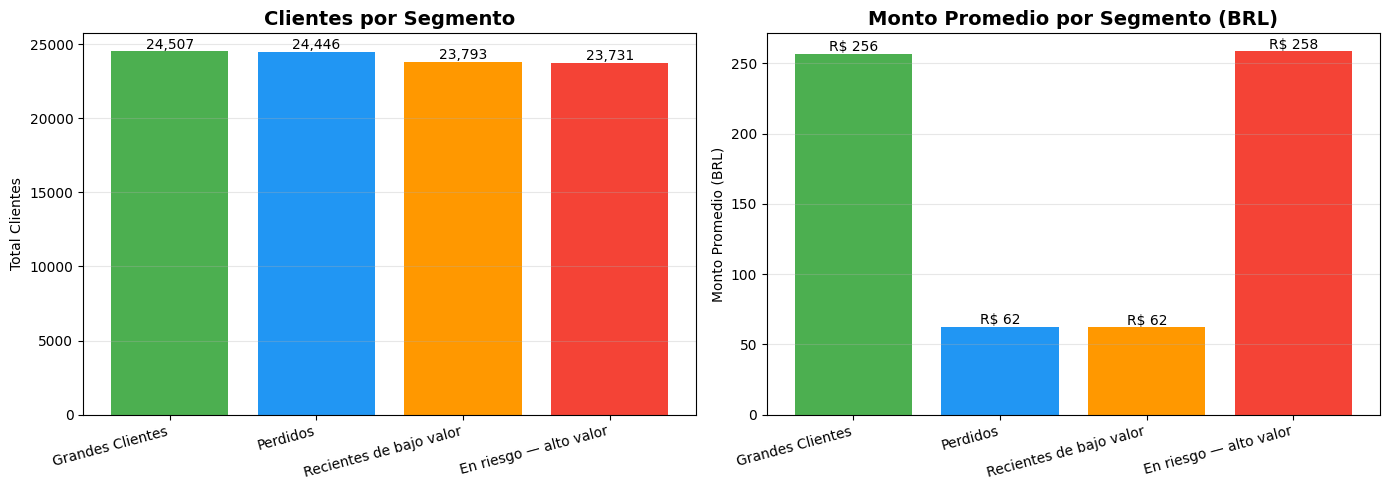

In [18]:
# Scoring RFM — dividimos en 4 cuartiles (1 al 4)
rfm['R_score'] = pd.qcut(rfm['recencia'], q=4, labels=[4, 3, 2, 1])
rfm['M_score'] = pd.qcut(rfm['monto'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)
rfm['RM_score'] = rfm['R_score'] + rfm['M_score']

# Segmentamos clientes
def segmentar(row):
    r = row['R_score']
    m = row['M_score']
    if r >= 3 and m >= 3:
        return 'Grandes Clientes'
    elif r >= 3 and m < 3:
        return 'Recientes de bajo valor'
    elif r < 3 and m >= 3:
        return 'En riesgo — alto valor'
    else:
        return 'Perdidos'

rfm['segmento'] = rfm.apply(segmentar, axis=1)

# Resumen por segmento
resumen = rfm.groupby('segmento').agg(
    total_clientes = ('customer_id', 'count'),
    recencia_prom  = ('recencia', 'mean'),
    monto_prom     = ('monto', 'mean')
).round(1).sort_values('total_clientes', ascending=False)

print("=== SEGMENTACIÓN DE CLIENTES ===\n")
print(resumen.to_string())

# Graficamos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Cantidad por segmento
colores = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
segmentos = resumen.index.tolist()
cantidades = resumen['total_clientes'].tolist()

bars = ax1.bar(segmentos, cantidades, color=colores)
ax1.set_title('Clientes por Segmento', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Clientes')
ax1.set_xticklabels(segmentos, rotation=15, ha='right')
for bar, val in zip(bars, cantidades):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2 — Monto promedio por segmento
montos = resumen['monto_prom'].tolist()
bars2 = ax2.bar(segmentos, montos, color=colores)
ax2.set_title('Monto Promedio por Segmento (BRL)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Monto Promedio (BRL)')
ax2.set_xticklabels(segmentos, rotation=15, ha='right')
for bar, val in zip(bars2, montos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'R$ {val:,.0f}', ha='center', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('olist_segmentacion_clientes.png', dpi=150, bbox_inches='tight')
plt.show()


Grandes Clientes (24,507)  
→  mejor activo, premios

En riesgo - alto valor (23,731)  
→ campañas de reactivación Son clientes que gastaron bien pero hace 366 días que no compran

Recientes de bajo valor (23,793)  
→ Incentivar a gastar más

Perdidos (24,446)  
→ No inviertir mucho, costo alto bajo retorno

In [20]:
# Unimos sellers con order_items, orders y reviews
df_sellers = orders_delivered[['order_id']].merge(order_items[['order_id', 'seller_id', 'price']], on='order_id')
df_sellers = df_sellers.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Métricas por vendedor
seller_metrics = df_sellers.groupby('seller_id').agg(
    total_ventas    = ('order_id', 'count'),
    ingresos        = ('price', 'sum'),
    score_promedio  = ('review_score', 'mean')
).round(2).reset_index()

seller_metrics['ingresos'] = seller_metrics['ingresos'].round(0)

# Filtramos vendedores con al menos 10 ventas para que sea representativo
seller_metrics = seller_metrics[seller_metrics['total_ventas'] >= 10]

print(f"Vendedores con 10+ ventas: {len(seller_metrics):,}")
print(f"\nTop 10 vendedores por ingresos:")
print(seller_metrics.nlargest(10, 'ingresos')[['seller_id', 'total_ventas', 'ingresos', 'score_promedio']].to_string(index=False))
print(f"\nTop 10 vendedores por satisfacción (mín 50 ventas):")
top_score = seller_metrics[seller_metrics['total_ventas'] >= 50].nlargest(10, 'score_promedio')
print(top_score[['seller_id', 'total_ventas', 'ingresos', 'score_promedio']].to_string(index=False))

Vendedores con 10+ ventas: 1,345

Top 10 vendedores por ingresos:
                       seller_id  total_ventas  ingresos  score_promedio
4869f7a5dfa277a7dca6462dcf3b52b2          1148  226988.0            4.14
53243585a1d6dc2643021fd1853d8905           400  217940.0            4.13
4a3ca9315b744ce9f8e9374361493884          1971  199408.0            3.83
fa1c13f2614d7b5c4749cbc52fecda94           579  190917.0            4.37
7c67e1448b00f6e969d365cea6b010ab          1366  188064.0            3.35
7e93a43ef30c4f03f38b393420bc753a           322  165981.0            4.36
da8622b14eb17ae2831f4ac5b9dab84a          1571  162304.0            4.08
7a67c85e85bb2ce8582c35f2203ad736          1159  140239.0            4.27
1025f0e2d44d7041d6cf58b6550e0bfa          1434  139720.0            3.87
955fee9216a65b617aa5c0531780ce60          1474  131907.0            4.09

Top 10 vendedores por satisfacción (mín 50 ventas):
                       seller_id  total_ventas  ingresos  score_promedio
d9bd9